# Multicollinearity and Influential Points

In this notebook we will identify multicollinearity in a set of predictors and demonstrate how it causes issues with modeling. We will also show how we can identify outliers, or **influential** points. We'll be using the **Credit** data for this exercise.

In [2]:
# Detect Multicollinearity 
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [ ]:
# 1. We want to create a heatmap for pairwise correlations

credit = pd.read_csv("../Data/Credit.csv")
credit['Income'] = pd.to_numeric(credit['Income'])
credit.sample(5)

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
189,190,58.351,4411,326,2,85,16,Female,No,Yes,Caucasian,126
389,390,83.948,7100,503,2,44,18,Male,No,No,Caucasian,806
183,184,80.861,4090,335,3,29,15,Female,No,Yes,Asian,0
275,276,163.329,8732,636,3,50,14,Male,No,Yes,Caucasian,529
21,22,37.348,6378,458,1,72,17,Female,No,No,Caucasian,968


In [4]:
# We need the numeric variables for the correlation matrix
quantitative_vars = [ 'Balance', 'Income', 'Limit', 'Rating', 'Cards', 'Age']

# Calculate the correlation matrix
corr_matrix = credit[quantitative_vars].corr()
corr_matrix

,Balance,Income,Limit,Rating,Cards,Age
Balance,1.000000,0.463656,0.861697,0.863625,0.086456,0.001835
Income,0.463656,1.000000,0.792088,0.791378,-0.018273,0.175338
Limit,0.861697,0.792088,1.000000,0.996880,0.010231,0.100888
Rating,0.863625,0.791378,0.996880,1.000000,0.053239,0.103165
Cards,0.086456,-0.018273,0.010231,0.053239,1.000000,0.042948
Age,0.001835,0.175338,0.100888,0.103165,0.042948,1.000000


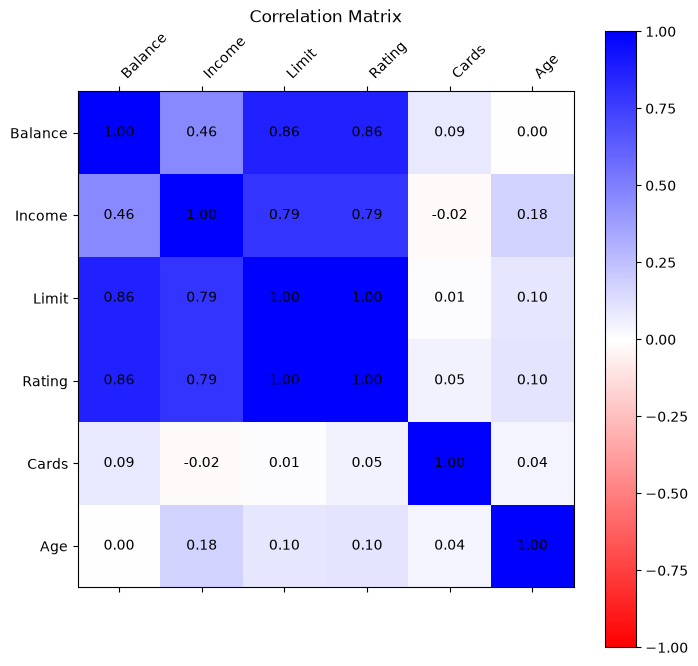

In [5]:
# For visulaization purposes, to spot highly correlated predictors, we can use a heatmap.
import matplotlib.colors as mcolors

# Create a custom diverging colormap where 0 is explicitly white
cmap = mcolors.LinearSegmentedColormap.from_list('custom_coolwarm', ['red', 'white', 'blue'], N=256)

# Create a plot to visualize the correlation matrix with white for zero
fig, ax = plt.subplots(figsize=(8, 8))

# Apply the custom colormap to the heatmap
cax = ax.matshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)

# Add color bar to the side
plt.colorbar(cax)

# Set the ticks for the x and y axis
ax.set_xticks(range(len(quantitative_vars)))
ax.set_yticks(range(len(quantitative_vars)))

# Set the labels for the ticks
ax.set_xticklabels(quantitative_vars, rotation=45, ha='left')
ax.set_yticklabels(quantitative_vars)

# Annotate the correlation matrix with the numeric values
for (i, j), val in np.ndenumerate(corr_matrix):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Display the plot
plt.title("Correlation Matrix")
plt.show()


### Note:

- We are only comparing quantitative predictors here, not categorical. 
- Think: how can we measure the "correlation" between categorical variables? Or categorical variables vs. quantitative variables? It is not straightforward.

### Problem with identifying with correlations:
- It characterizes pairwise relationships, but does not evaluate all features' joint correlations together.
- It doesn't make sense out of the box for categorical variables. 

We can use the variance inflation factors to identify predictors that are linear combinations of more than one other predictor since the correlation is only a pairwise metric.

In [6]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices #an alternative to basic pandas dfs.

y, X = dmatrices('Balance ~ Income + Limit + Rating + Cards + \
                  Age + Education + Gender + Student + Married + Ethnicity', 
                  data=credit, return_type='dataframe')

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
print(vif)

    VIF Factor                features
0    52.451853               Intercept
1     1.005849        Gender[T.Female]
2     1.031517          Student[T.Yes]
3     1.044638          Married[T.Yes]
4     1.552157      Ethnicity[T.Asian]
5     1.527504  Ethnicity[T.Caucasian]
6     2.786182                  Income
7   234.028100                   Limit
8   235.848259                  Rating
9     1.448690                   Cards
10    1.051410                     Age
11    1.019588               Education


Limit and Rating are identified as variables that are causing the multicolinearity problem. Since they are highly correlated, we can consider deleting one. Let's try to delete Limit.

In [ ]:
# Deleting limit improves VIFs considerably
y, X_new = dmatrices('Balance~ Income + Rating + Cards + \
                      Age + Education + Gender + Student + Married + Ethnicity', 
                      data=credit, return_type='dataframe')
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_new.values, i) for i in range(X_new.shape[1])]
vif["features"] = X_new.columns
print(vif)

# The intercept has a high VIF but this doesn't mean we should necessarily get rid of it. 
# If we do, we are assuming true proportionality between X and y... that's a big assumption. 
# Especially since from the summary table that it's not close to zero. 
# Btw - what are the null and alt hypotheses for that t - test? Do you remember? 

    VIF Factor                features
0    46.513331               Intercept
1     1.005848        Gender[T.Female]
2     1.022092          Student[T.Yes]
3     1.032237          Married[T.Yes]
4     1.546515      Ethnicity[T.Asian]
5     1.527415  Ethnicity[T.Caucasian]
6     2.784966                  Income
7     2.730561                  Rating
8     1.019639                   Cards
9     1.051135                     Age
10    1.013503               Education


In [10]:
# fit model with Limit AND rating 
model = smf.ols('Balance ~ Income + Limit +Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.11e-253
Time:                        10:21:06   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -479.2079     35.774    -13.395      0.000    -549.543    -408.873
Gender[T.Female]         -10.6532      9.914     -1.075      0.283     -30.145       8.839
Student[T.Yes]           425.7474     16.723     25.459      0.000     392.869     458.626
Married[T.Yes]            -8.5339     10.363     -0.824      0.411     -28.908      11.841
Ethnicity[T.Asian]        16.8042     14.119      1.190      0.235     -10.955      44.564
Ethnicity[T.Caucasian]    10.1070     12.210      0.828      0.408     -13.899      34.113
Income                    -7.8031      0.234    -33.314      0.000      -8.264      -7.343
Limit                      0.1909      0.033      5.824      0.000       0.126       0.255
Rating                     1.1365      0.491      2.315      0.021       0.171       2.102
Cards                     17.7245      4.341      4.083      0.000       9.190      26.259
Age                       -0.6139      0.294     -2.088      0.037      -1.192      -0.036
Education                 -1.0989      1.598     -0.688      0.492      -4.241       2.043
==============================================================================
Omnibus:                       34.899   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.766
Skew:                           0.782   Prob(JB):                     8.52e-10
Kurtosis:                       3.241   Cond. No.                     3.87e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.87e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# fit new model 
model = smf.ols('Balance ~ Income + Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     757.8
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          4.46e-248
Time:                        10:19:57   Log-Likelihood:                -2415.4
No. Observations:                 400   AIC:                             4853.
Df Residuals:                     389   BIC:                             4897.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -549.3140     35.085    -15.657      0.000    -618.293    -480.335
Gender[T.Female]         -10.7106     10.325     -1.037      0.300     -31.010       9.589
Student[T.Yes]           416.4376     17.336     24.021      0.000     382.353     450.522
Married[T.Yes]           -15.1096     10.728     -1.408      0.160     -36.202       5.983
Ethnicity[T.Asian]        21.7616     14.678      1.483      0.139      -7.096      50.619
Ethnicity[T.Caucasian]    10.6492     12.716      0.837      0.403     -14.351      35.649
Income                    -7.7746      0.244    -31.878      0.000      -8.254      -7.295
Rating                     3.9790      0.055     72.332      0.000       3.871       4.087
Cards                      3.9654      3.793      1.045      0.296      -3.492      11.422
Age                       -0.6416      0.306     -2.096      0.037      -1.243      -0.040
Education                 -0.3799      1.659     -0.229      0.819      -3.642       2.882
==============================================================================
Omnibus:                       15.651   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.769
Skew:                           0.490   Prob(JB):                     0.000228
Kurtosis:                       2.789   Cond. No.                     2.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

How different is the model above when we removed one of the highly correlated predictors? Take a look at the p-values for each coefficient, and look at the coefficients themselves. 

#### Perfect Collinearity

Let's create a feature that is perfectly correlated with one of our others and see what happens. You'll notice that the model will still be fit. The statsmodels library can still compute the inverse of the $X^TX$ matrix using a different method, but look at the very bottom of the summary, in the fine print. You'll see a *warning* about your matrix, which tells you not to fully trust the results.

In [15]:
# Create a new feature that is a linear combination of the two highly correlated features.
credit['Limit_Rating'] = credit['Limit']*2

# Fit a model with the new feature
model = smf.ols('Balance ~ Income + Rating + Limit + Limit_Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.11e-253
Time:                        10:34:26   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -479.2079     35.774    -13.395      0.000    -549.543    -408.873
Gender[T.Female]         -10.6532      9.914     -1.075      0.283     -30.145       8.839
Student[T.Yes]           425.7474     16.723     25.459      0.000     392.869     458.626
Married[T.Yes]            -8.5339     10.363     -0.824      0.411     -28.908      11.841
Ethnicity[T.Asian]        16.8042     14.119      1.190      0.235     -10.955      44.564
Ethnicity[T.Caucasian]    10.1070     12.210      0.828      0.408     -13.899      34.113
Income                    -7.8031      0.234    -33.314      0.000      -8.264      -7.343
Rating                     1.1365      0.491      2.315      0.021       0.171       2.102
Limit                      0.0382      0.007      5.824      0.000       0.025       0.051
Limit_Rating               0.0764      0.013      5.824      0.000       0.051       0.102
Cards                     17.7245      4.341      4.083      0.000       9.190      26.259
Age                       -0.6139      0.294     -2.088      0.037      -1.192      -0.036
Education                 -1.0989      1.598     -0.688      0.492      -4.241       2.043
==============================================================================
Omnibus:                       34.899   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.766
Skew:                           0.782   Prob(JB):                     8.52e-10
Kurtosis:                       3.241   Cond. No.                     1.77e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.76e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

## Influential points

Now let's see if we can identify influential points.

In [ ]:
#object for the analysis of influential points
infl = model.get_influence()
#members
print(dir(infl)) #these are all the things inside the infl variable
#we will only use some of this... there's a ton of extra stuff

## How to find the externally studentized residuals:

In [ ]:
#externally studentized residuals
print(infl.resid_studentized_external[1:5]) #just the first 5 obs as example

## How to visualize leverage, externally studentized residuals, and Cook's distance with an "Influence Plot":

In [ ]:
#graphical representation of the influence of each observation
fig, ax = plt.subplots(figsize=(12,12))
fig=sm.graphics.influence_plot(model, ax=ax, criterion="cooks") 
#size of points are given by cook's dist value
#the points with massive size whose studentized resids lie outside the range from (-3,3) should raise a "yellow" flag

In [ ]:
infl.hat_diag_factor

## Thresholding externally studentized residuals


In [ ]:
import scipy
n=400
p=11

tstar_stud = scipy.stats.t.ppf(0.975,df=n-p-1) # t quantile at 97.5 %ile
#detection - absolute value > threshold
reg_studs=infl.resid_studentized_external
atyp_stud = np.abs(reg_studs) > tstar_stud
#which ones?
print(credit.index[atyp_stud],reg_studs[atyp_stud])

## Thresholding Cook's D

In [ ]:
#Cook's distance
inflsum=infl.summary_frame()
reg_cook=inflsum.cooks_d

atyp_cook = np.abs(reg_cook) >= 4/n
print(credit.index[atyp_cook],reg_cook[atyp_cook])

#### These observations should be looked at more carefully. Consider both including/excluding points and see if it has a large difference on your model/coefs. 
